# LGBM & XGBM

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [6]:
train_data=pd.read_csv('Titanic_train.csv')
test_data=pd.read_csv('Titanic_test.csv')

# Exploratory Data Analysis (EDA):

In [7]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [9]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

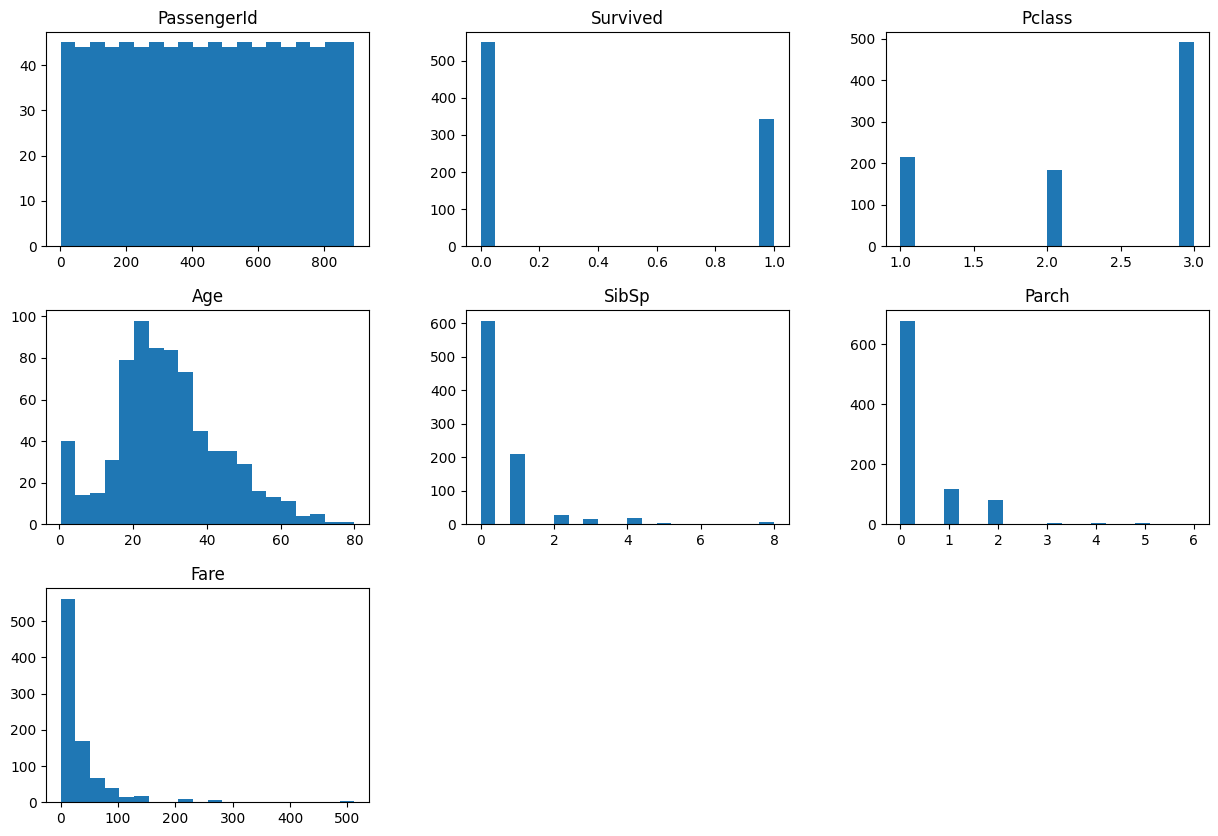

In [11]:
#Histogram
train_data.hist(bins=20,figsize=(15,10),grid=False)
plt.show()

<Axes: >

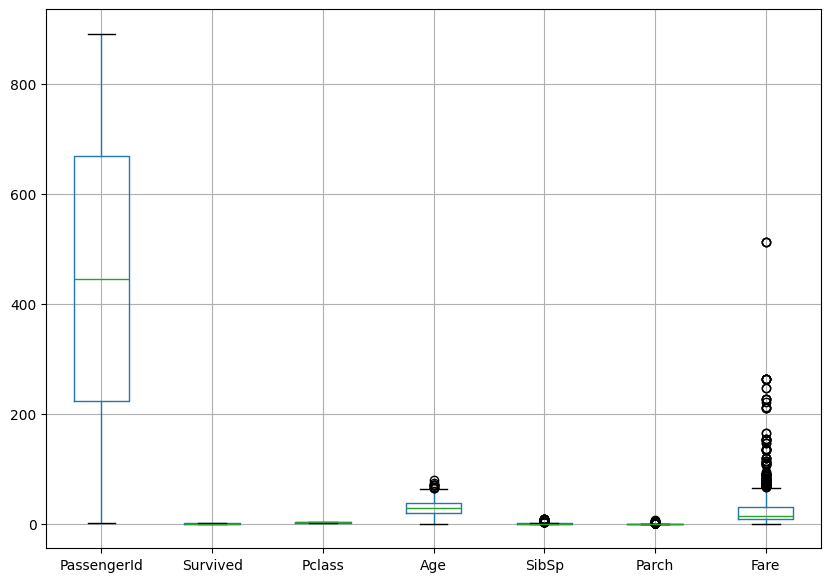

In [12]:
#Box Plot
plt.figure(figsize=(10,7))
train_data.boxplot()

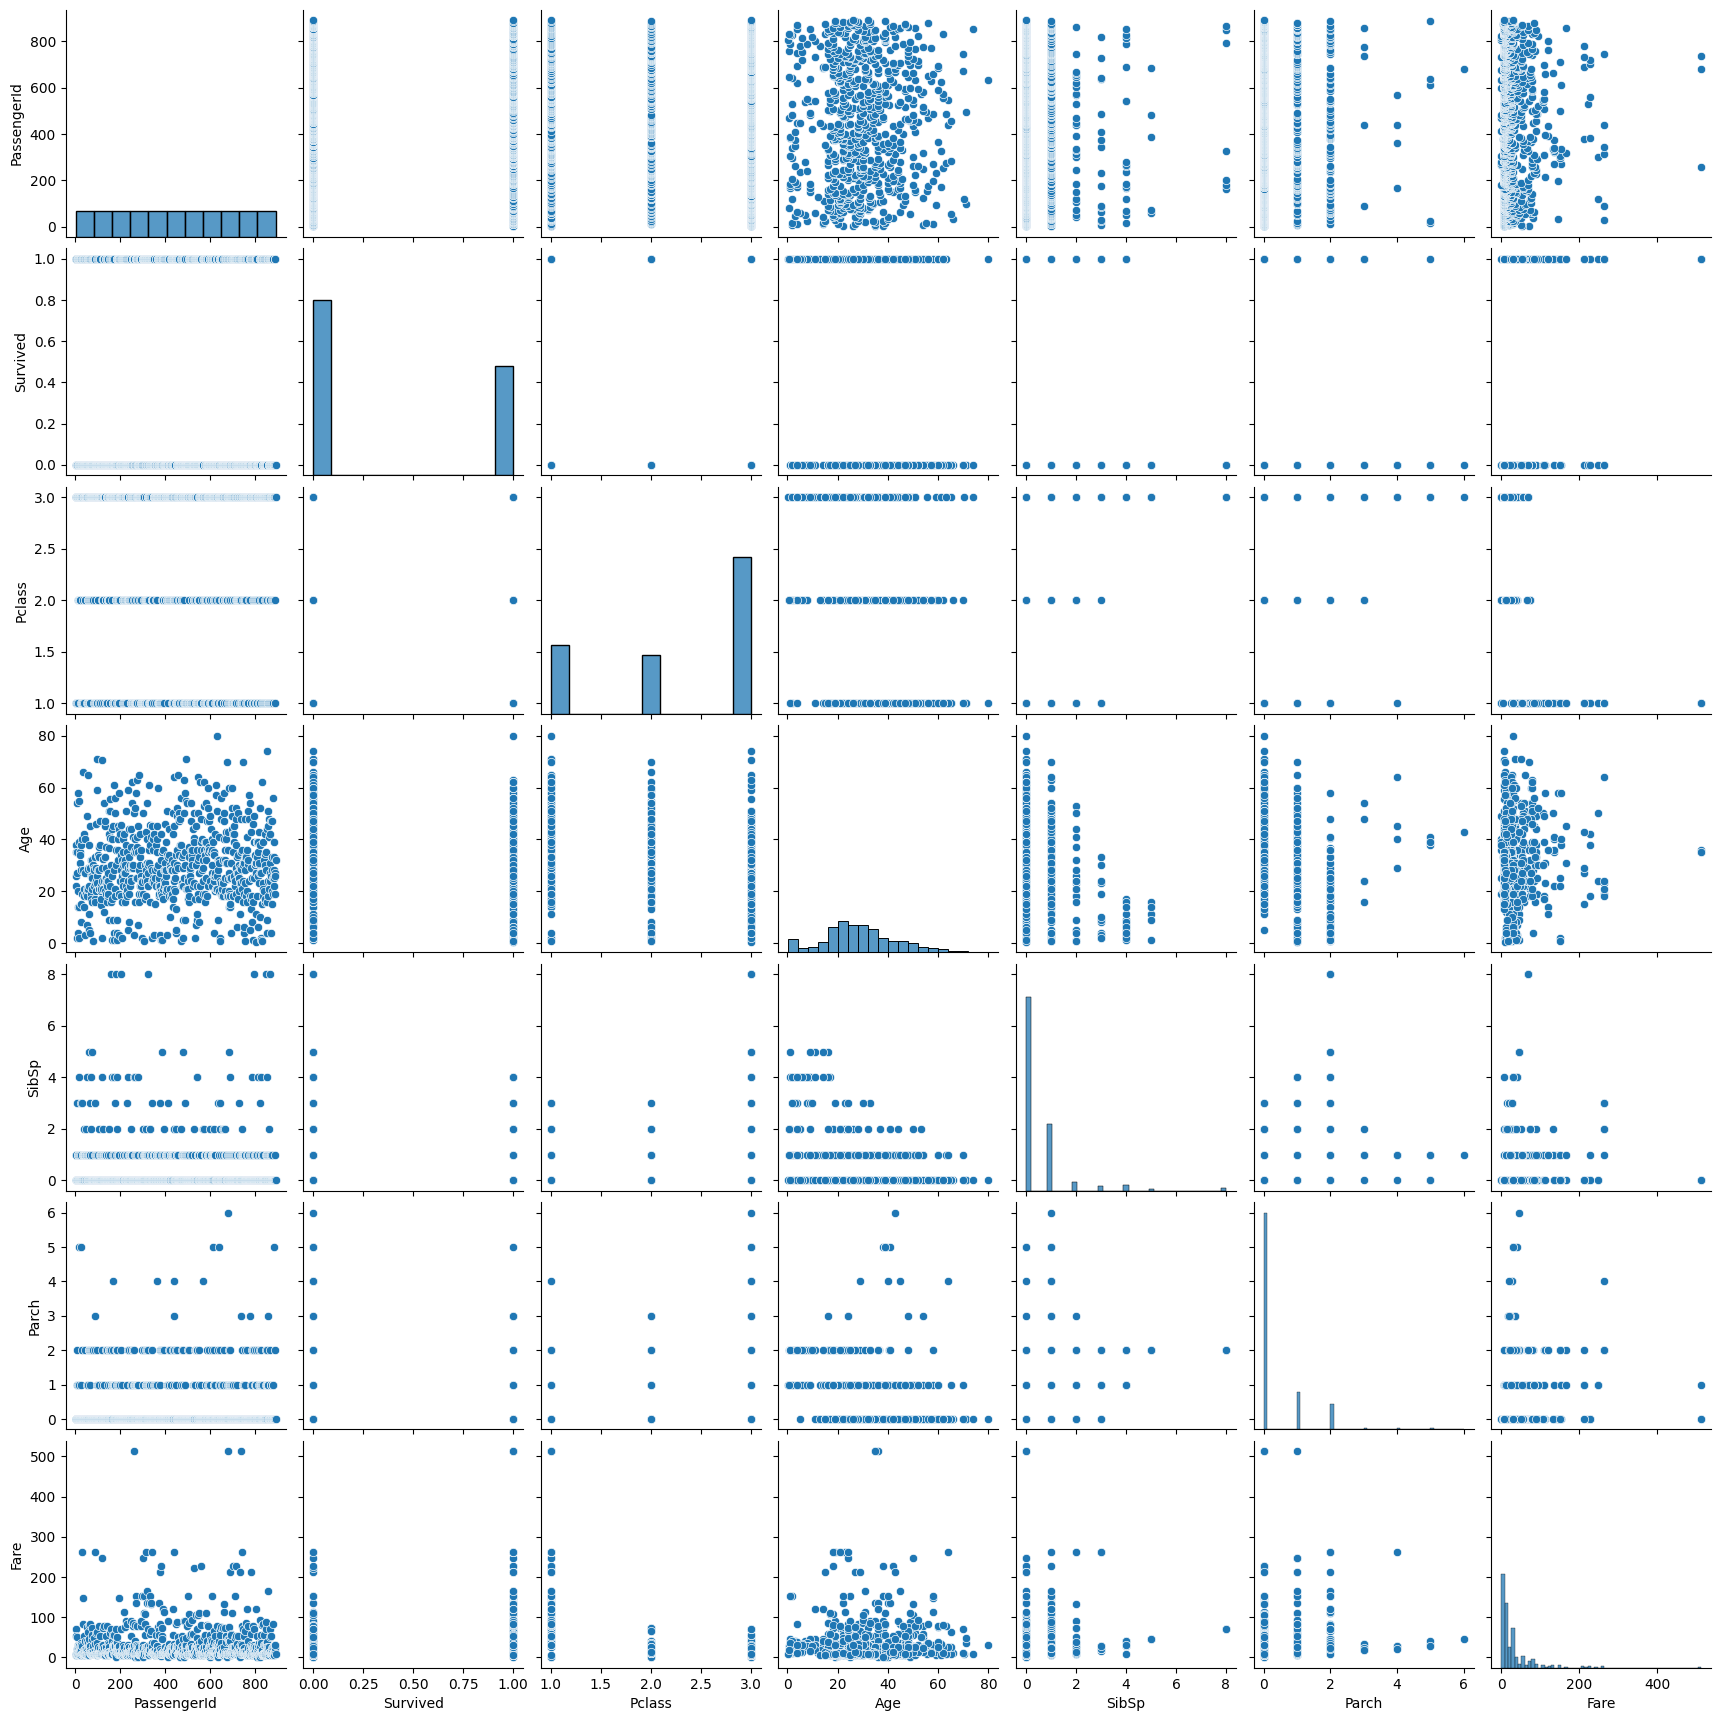

In [13]:
#Pair Plot
sns.pairplot(train_data)

# Data Preprocessing:

In [14]:
#imputing the missing values
train_data['Age']=train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked']=train_data['Embarked'].fillna(train_data['Embarked'].mode())
test_data['Age']=test_data['Age'].fillna(test_data['Age'].mean())
test_data['Embarked']=test_data['Embarked'].fillna(test_data['Embarked'].mode())


In [15]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
train_data.drop(['Name','Ticket'],axis=1,inplace=True)
test_data.drop(['Name','Ticket'],axis=1,inplace=True)

In [17]:
train_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,NaN,S
1,2,1,1,female,38.000000,1,0,71.2833,C85,C
2,3,1,3,female,26.000000,0,0,7.9250,NaN,S
3,4,1,1,female,35.000000,1,0,53.1000,C123,S
4,5,0,3,male,35.000000,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,NaN,S
887,888,1,1,female,19.000000,0,0,30.0000,B42,S
888,889,0,3,female,29.699118,1,2,23.4500,NaN,S
889,890,1,1,male,26.000000,0,0,30.0000,C148,C


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le=LabelEncoder()

In [20]:
train_data['Cabin']=le.fit_transform(train_data['Cabin'])
test_data['Cabin']=le.fit_transform(test_data['Cabin'])

In [21]:
train_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,147,S
1,2,1,1,female,38.000000,1,0,71.2833,81,C
2,3,1,3,female,26.000000,0,0,7.9250,147,S
3,4,1,1,female,35.000000,1,0,53.1000,55,S
4,5,0,3,male,35.000000,0,0,8.0500,147,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,147,S
887,888,1,1,female,19.000000,0,0,30.0000,30,S
888,889,0,3,female,29.699118,1,2,23.4500,147,S
889,890,1,1,male,26.000000,0,0,30.0000,60,C


In [22]:
dum=pd.get_dummies(train_data[['Sex','Embarked']])
dumm=pd.get_dummies(test_data[['Sex','Embarked']])

In [23]:
train_data.drop(['Sex','Embarked'],axis=1,inplace=True)
test_data.drop(['Sex','Embarked'],axis=1,inplace=True)

In [24]:
train_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin
0,1,0,3,22.000000,1,0,7.2500,147
1,2,1,1,38.000000,1,0,71.2833,81
2,3,1,3,26.000000,0,0,7.9250,147
3,4,1,1,35.000000,1,0,53.1000,55
4,5,0,3,35.000000,0,0,8.0500,147
...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,147
887,888,1,1,19.000000,0,0,30.0000,30
888,889,0,3,29.699118,1,2,23.4500,147
889,890,1,1,26.000000,0,0,30.0000,60


In [25]:
test_data

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Cabin
0,892,3,34.50000,0,0,7.8292,76
1,893,3,47.00000,1,0,7.0000,76
2,894,2,62.00000,0,0,9.6875,76
3,895,3,27.00000,0,0,8.6625,76
4,896,3,22.00000,1,1,12.2875,76
...,...,...,...,...,...,...,...
413,1305,3,30.27259,0,0,8.0500,76
414,1306,1,39.00000,0,0,108.9000,22
415,1307,3,38.50000,0,0,7.2500,76
416,1308,3,30.27259,0,0,8.0500,76


In [26]:
df=train_data.join(dum,how='left')
df1=test_data.join(dumm,how='left')

In [27]:
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.000000,1,0,7.2500,147,False,True,False,False,True
1,2,1,1,38.000000,1,0,71.2833,81,True,False,True,False,False
2,3,1,3,26.000000,0,0,7.9250,147,True,False,False,False,True
3,4,1,1,35.000000,1,0,53.1000,55,True,False,False,False,True
4,5,0,3,35.000000,0,0,8.0500,147,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,147,False,True,False,False,True
887,888,1,1,19.000000,0,0,30.0000,30,True,False,False,False,True
888,889,0,3,29.699118,1,2,23.4500,147,True,False,False,False,True
889,890,1,1,26.000000,0,0,30.0000,60,False,True,True,False,False


In [28]:
df1

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,34.50000,0,0,7.8292,76,False,True,False,True,False
1,893,3,47.00000,1,0,7.0000,76,True,False,False,False,True
2,894,2,62.00000,0,0,9.6875,76,False,True,False,True,False
3,895,3,27.00000,0,0,8.6625,76,False,True,False,False,True
4,896,3,22.00000,1,1,12.2875,76,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,30.27259,0,0,8.0500,76,False,True,False,False,True
414,1306,1,39.00000,0,0,108.9000,22,True,False,True,False,False
415,1307,3,38.50000,0,0,7.2500,76,False,True,False,False,True
416,1308,3,30.27259,0,0,8.0500,76,False,True,False,False,True


In [29]:
from sklearn.model_selection import train_test_split

In [30]:
features=df.drop(['Survived'],axis=1)

In [31]:
target=df['Survived']

In [32]:
features

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,3,22.000000,1,0,7.2500,147,False,True,False,False,True
1,2,1,38.000000,1,0,71.2833,81,True,False,True,False,False
2,3,3,26.000000,0,0,7.9250,147,True,False,False,False,True
3,4,1,35.000000,1,0,53.1000,55,True,False,False,False,True
4,5,3,35.000000,0,0,8.0500,147,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,27.000000,0,0,13.0000,147,False,True,False,False,True
887,888,1,19.000000,0,0,30.0000,30,True,False,False,False,True
888,889,3,29.699118,1,2,23.4500,147,True,False,False,False,True
889,890,1,26.000000,0,0,30.0000,60,False,True,True,False,False


In [33]:
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [34]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.3,random_state=42)

# Building Predictive Models:

In [35]:
#pip install XGBoost

In [36]:
#pip install lightgbm

### LGBM (LightGB Model)

In [37]:
import lightgbm as lgb

In [38]:
model=lgb.LGBMClassifier()

In [39]:
model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 231, number of negative: 392
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 623, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370787 -> initscore=-0.528844
[LightGBM] [Info] Start training from score -0.528844
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
y_pred=model.predict(x_test)

In [41]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score

In [42]:
accuracy_score(y_test,y_pred)

0.8134328358208955

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       157
           1       0.83      0.69      0.75       111

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



### XGBoost

In [44]:
from xgboost import XGBClassifier

In [45]:
model2=XGBClassifier()

In [46]:
model2.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [47]:
y_preds=model2.predict(x_test)

In [48]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       157
           1       0.81      0.71      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
params = {'learning_rate':[0.2,0.3,0.4,0.5], 'max_depth':[2,3,4,5], 'min_child_weight':[2,3,4,5],'n_estimators':[80,60,70,90]}

In [51]:
warnings.simplefilter('ignore')
grid = GridSearchCV(lgb.LGBMClassifier(),params,scoring='accuracy')
grid.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 184, number of negative: 314
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 377
[LightGBM] [Info] Number of data points in the train set: 498, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369478 -> initscore=-0.534457
[LightGBM] [Info] Start training from score -0.534457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.2, 0.3, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [2, 3, ...], 'n_estimators': [80, 60, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [52]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 80}


In [53]:
import xgboost as xgb

In [54]:
param={
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [50, 100]
}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss'), param, cv=3, scoring='accuracy')
grid_xgb.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01], 'max_depth': [3, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [55]:
print(grid_xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


# Comparative Analysis:

In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       157
           1       0.83      0.69      0.75       111

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [57]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       157
           1       0.81      0.71      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [58]:
lgb_accuracy=accuracy_score(y_test,y_pred)*100
lgb_precision=precision_score(y_test,y_pred)*100
lgb_recall=recall_score(y_test,y_pred)*100
lgb_f1score=f1_score(y_test,y_pred)*100

In [59]:
xgb_accuracy=accuracy_score(y_test,y_preds)*100
xgb_precision=precision_score(y_test,y_preds)*100
xgb_recall=recall_score(y_test,y_preds)*100
xgb_f1score=f1_score(y_test,y_preds)*100

In [60]:
metrics={
    'Metrics':['Accuracy','Precision','Recall','F1'],
    'LGBoost':[lgb_accuracy,lgb_precision,lgb_recall,lgb_f1score],
    'XGBoost':[xgb_accuracy,xgb_precision,xgb_recall,xgb_f1score]
}

In [61]:
metrics_df=pd.DataFrame(metrics)
metrics_df

,Metrics,LGBoost,XGBoost
0,Accuracy,81.343284,80.970149
1,Precision,82.795699,80.612245
2,Recall,69.369369,71.171171
3,F1,75.490196,75.598086


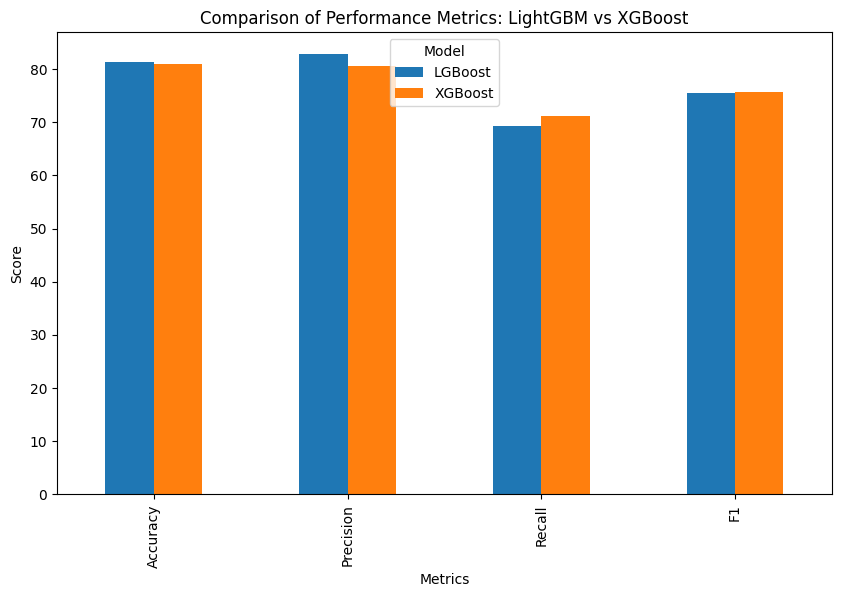

In [62]:
#Visualizations between LightGBM and XGBoost
metrics_df.plot(x='Metrics', kind='bar', figsize=(10, 6))
plt.title("Comparison of Performance Metrics: LightGBM vs XGBoost")
plt.ylabel("Score")
plt.legend(title="Model")
plt.show()